# Load time dataset

In [1]:
#setup
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
Timeline = pd.read_csv("../data/Tourism_Rome.csv", skiprows=6, header=[0, 1])
Timeline = Timeline.iloc[1:].reset_index(drop=True)

Timeline.head()

Indicatore                      Arrivi                           \
  Tipologia di esercizio   Totale esercizi ricettivi   Esercizi alberghieri     
0                2023-01                        581156                 463460   
1                2023-02                        596923                 477391   
2                2023-03                        787147                 626547   
3                2023-04                        899874                 700136   
4                2023-05                        983629                 764387   

                                                Presenze    \
  Esercizi extra-alberghieri   Totale esercizi ricettivi     
0                       117696                     2418079   
1                       119532                     2487245   
2                       160600                     3156680   
3                       199738                     3682617   
4                       219242                     3944900   

                                                       
  Esercizi alberghieri   Esercizi extra-alberghieri    
0                1823784                       594295  
1                1902985                       584260  
2                2375254                       781426  
3                2684479                       998138  
4                2811086                      1133814

In [3]:
Timeline.columns = [
    "Date",
    "Arrivals_Total",
    "Arrivals_Hotel",
    "Arrivals_NonHotel",
    "Overnights_Total",
    "Overnights_Hotel",
    "Overnights_NonHotel",
]
Timeline.head()

,Date,Arrivals_Total,Arrivals_Hotel,Arrivals_NonHotel,Overnights_Total,Overnights_Hotel,Overnights_NonHotel
0,2023-01,581156,463460,117696,2418079,1823784,594295
1,2023-02,596923,477391,119532,2487245,1902985,584260
2,2023-03,787147,626547,160600,3156680,2375254,781426
3,2023-04,899874,700136,199738,3682617,2684479,998138
4,2023-05,983629,764387,219242,3944900,2811086,1133814


# Seasonality: month of the year vs. number of tourists

We look at the hotel-related series (`Arrivals_Hotel`, `Overnights_Hotel`) to see how
tourist volume varies across the calendar year. Because `Date` is only 24 monthly
points (Jan 2023 - Dec 2024), a single Pearson coefficient against a raw month
number wouldn't capture a cyclical pattern (e.g. a summer peak, low in winter). So
instead we average each metric by calendar month across the two years and read the
seasonal shape directly off the bars.

In [4]:
# Numbers were read in as strings; convert the metric columns to numeric
metric_cols = [
    "Arrivals_Total",
    "Arrivals_Hotel",
    "Arrivals_NonHotel",
    "Overnights_Total",
    "Overnights_Hotel",
    "Overnights_NonHotel",
]
for col in metric_cols:
    Timeline[col] = pd.to_numeric(Timeline[col])

Timeline["Date"] = Timeline["Date"].str.strip()
Timeline["Date_parsed"] = pd.to_datetime(Timeline["Date"], format="%Y-%m")
Timeline["Month_num"] = Timeline["Date_parsed"].dt.month

Timeline.dtypes

Date                              str
Arrivals_Total                  int64
Arrivals_Hotel                  int64
Arrivals_NonHotel               int64
Overnights_Total                int64
Overnights_Hotel                int64
Overnights_NonHotel             int64
Date_parsed            datetime64[us]
Month_num                       int32
dtype: object

In [5]:
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_avg_hotel = (
    Timeline.groupby("Month_num")[["Arrivals_Hotel", "Overnights_Hotel"]]
    .mean()
    .reindex(range(1, 13))
)
monthly_avg_hotel.index = MONTH_ORDER
monthly_avg_hotel

,Arrivals_Hotel,Overnights_Hotel
Jan,483002.0,1800729.0
Feb,527175.0,2028653.5
Mar,667044.5,2532896.0
Apr,732607.0,2742919.0
May,807528.5,3012030.5
Jun,809458.0,2943372.5
Jul,820265.0,3103056.0
Aug,723338.5,2688813.5
Sep,771734.0,2822398.0
Oct,798511.5,2927859.0


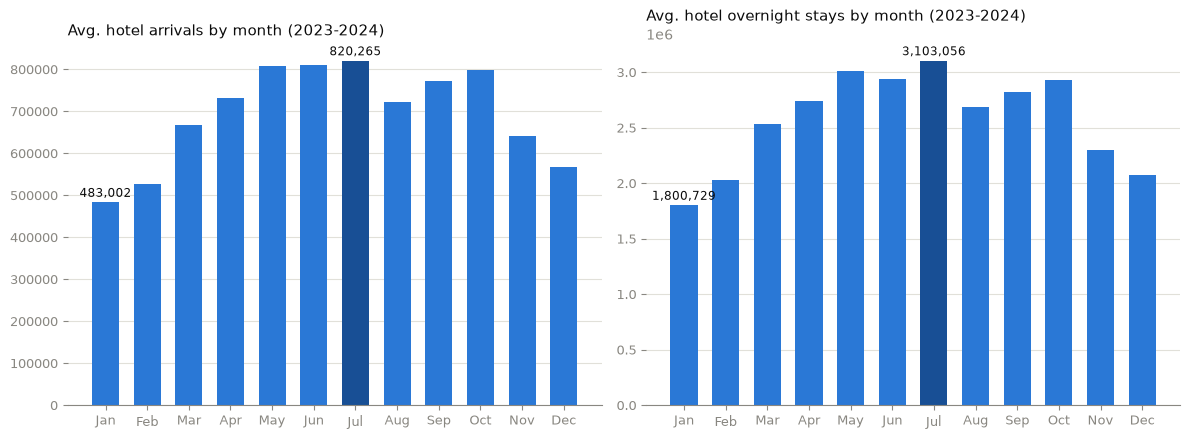

In [6]:
import matplotlib.pyplot as plt

BLUE = "#2a78d6"       # bars
BLUE_DARK = "#184f95"  # peak-month highlight
INK = "#0b0b0b"        # value labels / titles
MUTED = "#898781"      # axis ticks
GRID = "#e1e0d9"       # hairline gridlines

metrics = [
    ("Arrivals_Hotel", "Avg. hotel arrivals by month (2023-2024)"),
    ("Overnights_Hotel", "Avg. hotel overnight stays by month (2023-2024)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (col, title) in zip(axes, metrics):
    values = monthly_avg_hotel[col]
    peak_month = values.idxmax()
    low_month = values.idxmin()
    colors = [BLUE_DARK if m == peak_month else BLUE for m in values.index]

    ax.bar(values.index, values.values, color=colors, width=0.65)

    ax.set_title(title, fontsize=11, color=INK, loc="left")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(axis="x", colors=MUTED, labelsize=9)
    ax.tick_params(axis="y", colors=MUTED, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

    # direct labels only on the peak and the low month
    for month, val in values.items():
        if month in (peak_month, low_month):
            ax.annotate(
                f"{val:,.0f}",
                xy=(month, val),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                fontsize=8.5,
                color=INK,
            )

plt.tight_layout()
plt.show()

## Heatmap: seasonality by month

A heatmap version of the monthly averages above: one strip per metric, with
calendar month across the columns. This makes the seasonal shape (the summer
peak, the winter dip) easy to read as color rather than bar height.

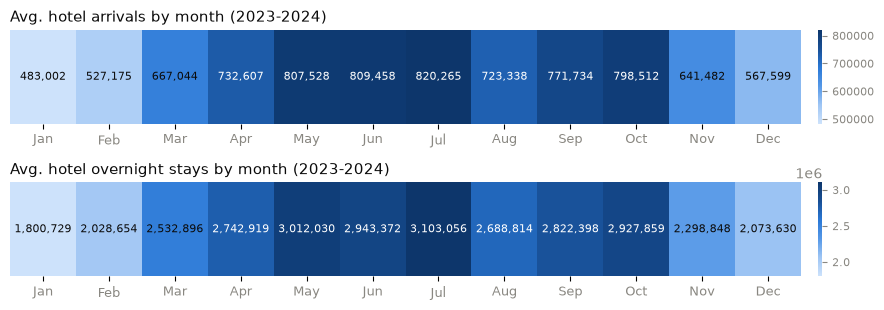

In [7]:
from matplotlib.colors import LinearSegmentedColormap

# Sequential ramp, same blue hue family as the bar chart above (light -> dark)
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"]
)

heat_metrics = [
    ("Arrivals_Hotel", "Avg. hotel arrivals by month (2023-2024)"),
    ("Overnights_Hotel", "Avg. hotel overnight stays by month (2023-2024)"),
]

fig, axes = plt.subplots(2, 1, figsize=(9, 3.2))

for ax, (col, title) in zip(axes, heat_metrics):
    values = monthly_avg_hotel[col].values.reshape(1, -1)

    im = ax.imshow(values, cmap=SEQ_BLUE, aspect="auto")

    ax.set_title(title, fontsize=11, color=INK, loc="left")
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_ORDER, fontsize=9, color=MUTED)
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # direct value labels; flip to white ink on the darkest cells for contrast
    vmin, vmax = values.min(), values.max()
    for x, val in enumerate(values[0]):
        frac = (val - vmin) / (vmax - vmin)
        label_color = "#ffffff" if frac > 0.6 else INK
        ax.text(x, 0, f"{val:,.0f}", ha="center", va="center",
                fontsize=8, color=label_color)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=8, colors=MUTED)
    cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

## Seasonality index: a single 0-1 coefficient per month

`Arrivals_Hotel` and `Overnights_Hotel` live on very different scales, so they
can't be combined directly. We min-max normalize each metric across the 12
months (0 = the lowest month, 1 = the highest month for that metric), then
combine them into one weighted composite:

`Seasonality_Index = 0.3 * norm(Arrivals_Hotel) + 0.7 * norm(Overnights_Hotel)`

Overnight stays get more weight (0.7) because they better reflect how long
tourists actually stay in Rome, while arrivals (0.3) only count how many
check in.

In [8]:
WEIGHTS = {"Arrivals_Hotel": 0.3, "Overnights_Hotel": 0.7}

normalized_hotel = (monthly_avg_hotel - monthly_avg_hotel.min()) / (
    monthly_avg_hotel.max() - monthly_avg_hotel.min()
)

seasonality_index = (
    normalized_hotel["Arrivals_Hotel"] * WEIGHTS["Arrivals_Hotel"]
    + normalized_hotel["Overnights_Hotel"] * WEIGHTS["Overnights_Hotel"]
)
seasonality_index.name = "Seasonality_Index"
seasonality_index.round(3)

Jan    0.000
Feb    0.162
Mar    0.557
Apr    0.728
May    0.940
Jun    0.905
Jul    1.000
Aug    0.691
Sep    0.806
Oct    0.886
Nov    0.409
Dec    0.222
Name: Seasonality_Index, dtype: float64

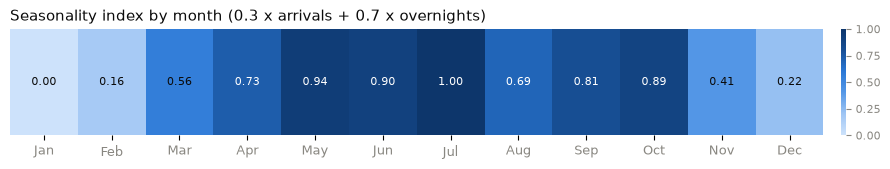

In [9]:
fig, ax = plt.subplots(figsize=(9, 1.8))

values = seasonality_index.values.reshape(1, -1)
im = ax.imshow(values, cmap=SEQ_BLUE, aspect="auto", vmin=0, vmax=1)

ax.set_title("Seasonality index by month (0.3 x arrivals + 0.7 x overnights)",
             fontsize=11, color=INK, loc="left")
ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_ORDER, fontsize=9, color=MUTED)
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

for x, val in enumerate(values[0]):
    label_color = "#ffffff" if val > 0.6 else INK
    ax.text(x, 0, f"{val:.2f}", ha="center", va="center",
            fontsize=8, color=label_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.tick_params(labelsize=8, colors=MUTED)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()